# INIT

In [1]:
import glob
import zipfile

import pandas as pd
pd.options.display.max_columns = 300
pd.options.display.max_rows = 300
pd.options.display.max_colwidth = 300

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

import warnings

warnings.filterwarnings("ignore")

pattern_csv = "train_data/dataset_*/*.csv"
pattern_xlsx = "train_data/dataset_*/*.xlsx"
pattern_parquet = "train_data/dataset_*/*.parquet"

csv_files = glob.glob(pattern_csv)
xlsx_files = glob.glob(pattern_xlsx)
parquet_files = glob.glob(pattern_parquet)

list_of_inputs = [] 

for i in range(len(csv_files)):
    some = pd.read_csv(csv_files[i])
    list_of_inputs.append(some)

for i in range(len(xlsx_files)):
    some = pd.read_excel(xlsx_files[i])
    list_of_inputs.append(some)

for i in range(len(parquet_files)):
    some = pd.read_parquet(parquet_files[i])
    list_of_inputs.append(some)

dfx = pd.concat(list_of_inputs)
dfy = pd.read_csv('train_data/y_train_base.csv')
dfxtst = pd.read_csv('train_data/X_test_base.csv')

dfx = dfx.drop_duplicates()
dfx = dfx.drop_duplicates(subset=['car_id'], keep='first')

In [2]:
dfx

,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Исползование,КПП,Двигатель,Привод,Топливо,Расход,Пробег,Цвет,Локация,Количество цилиндров,Тип кузова,Двери,Количество кресел,Оценка эксперта,Количество владельцев,Предложение
0,8de732ab-135d-4970-8316-db18a366ad1f,NISSAN,2019.0,NAVARA,UTE / TRAY,2019 NISSAN NAVARA ST (4X4),USED,Automatic,"4 cyl, 2.3 L",4WD,DIESEL,7 L / 100 km,85834,Grey / -,"ROBINA, QLD",4 cyl,UTE / TRAY,4 Doors,5 Seats,1.0,5.0,39422.0
1,977b4389-f2fd-4f34-b64a-0aecab6b832a,FORD,2015.0,EVEREST,SUV,2015 FORD EVEREST TITANIUM,USED,Automatic,"5 cyl, 3.2 L",AWD,DIESEL,8.5 L / 100 km,75210,Red / -,"SOUTH NOWRA, NSW",5 cyl,SUV,4 Doors,7 Seats,1.0,2.0,39895.0
2,77071bc7-8b0a-4404-ba1a-50f2302697eb,TOYOTA,2013.0,CAMRY,SEDAN,2013 TOYOTA CAMRY ALTISE,USED,Automatic,"4 cyl, 2.5 L",Front,UNLEADED,7.8 L / 100 km,194033,Black / -,"HERMIT PARK, QLD",4 cyl,SEDAN,4 Doors,5 Seats,4.0,6.0,14577.0
3,22c1132a-b9a0-4ca1-b6f6-38919178d133,MAZDA,2023.0,CX-30,DEMO,2023 MAZDA CX-30 G20 TOURING,DEMO,Automatic,-,Other,UNLEADED,-,3038,Grey / Black Leather,"SOUTHPORT, QLD",-,SUV,NaN,NaN,3.0,7.0,37075.0
4,03ec190c-8629-4451-9de5-9472f5211a02,BENTLEY,2015.0,CONTINENTAL,COUPE,2015 BENTLEY CONTINENTAL GT V8 S,USED,Automatic,"8 cyl, 4 L",AWD,PREMIUM,10.5 L / 100 km,53266,- / -,"ROZELLE, NSW",8 cyl,COUPE,2 Doors,4 Seats,4.0,2.0,179694.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,524f8dce-f13f-4729-ad13-465a9bec84b4,MITSUBISHI,2012.0,PAJERO,SUV,2012 MITSUBISHI PAJERO GLX LWB (4X4),USED,Automatic,"4 cyl, 3.2 L",4WD,DIESEL,9 L / 100 km,186726,Grey / Black,"TOOWOOMBA CITY, QLD",4 cyl,SUV,4 Doors,7 Seats,9.0,4.0,25714
170,7821a011-7bce-44e6-815a-80ea209f3a65,MERCEDES-BENZ,2018.0,C250,WAGON,2018 MERCEDES-BENZ C250 D,USED,Automatic,"4 cyl, 2.1 L",Rear,DIESEL,4.8 L / 100 km,78038,Silver / -,"ALEXANDRIA, NSW",4 cyl,WAGON,4 Doors,4 Seats,9.0,2.0,41551
171,02c62264-a6f9-43e9-9ee0-c7206f9e8e8a,MERCEDES-BENZ,2017.0,GLE63,SUV,2017 MERCEDES-BENZ GLE63 S 4MATIC,USED,Automatic,"8 cyl, 5.5 L",AWD,PREMIUM,11.8 L / 100 km,59982,Black / -,"CROYDON, NSW",8 cyl,SUV,4 Doors,5 Seats,2.0,3.0,112962
172,06c86dee-8ff2-45bf-b987-ff222937594b,TOYOTA,2021.0,RAV4,SUV,2021 TOYOTA RAV4 CRUISER (2WD),USED,Automatic,"4 cyl, 2 L",Front,UNLEADED,6.5 L / 100 km,24022,Silver / Black,"CROYDON, VIC",4 cyl,SUV,5 Doors,5 Seats,8.0,2.0,46120


# Preprocessing

In [ ]:
def preproc(df, train):
    # attributes
    df['Цилиндры'] = pd.to_numeric(
        df['Двигатель'].str.extract(r'(\d+)\s*cyl')[0], 
        errors='coerce'
    ).astype('Int64')

    df['Объем_двигателя'] = pd.to_numeric(
        df['Двигатель'].str.extract(r'([\d\.]+)\s*L')[0], 
        errors='coerce'
    )

    df['Расход_число'] = pd.to_numeric(
        df['Расход'].str.extract(r'([\d\.]+)\s*L')[0], 
        errors='coerce'
    )

    df['Двери_число'] = pd.to_numeric(
        df['Двери'].str.extract(r'(\d+)\s*Doors')[0], 
        errors='coerce'
    )

    df['Кресла_число'] = pd.to_numeric(
        df['Количество кресел'].str.extract(r'(\d+)\s*Seats')[0], 
        errors='coerce'
    )

    medianes = {
        "median_cyl" : df["Цилиндры"].median(),
        "median_vol" : df["Объем_двигателя"].median(),
        "median_cons" : df["Расход_число"].median(),
        "median_doors" : df["Двери_число"].median(),
        "median_seats" : df["Кресла_число"].median()
    }


    # text NaN filling
    cols = ["Полное название", "Бренд", "Модель", "Тип машины", "Локация", "Цвет", "Тип кузова"]
    for col in cols:
        if col in df.columns:
            df[col] = df[col].fillna('unknown').astype(str)

    df["КПП"] = df["КПП"].replace('-', 'Automatic')
    df = pd.get_dummies(df, columns=["Исползование"], drop_first=True, dtype=int)
    df = pd.get_dummies(df, columns=["КПП"], drop_first=True, dtype=int)
    df = pd.get_dummies(df, columns=["Привод"], drop_first=True, dtype=int)
    df = pd.get_dummies(df, columns=["Топливо"], drop_first=True, dtype=int)
    df = pd.get_dummies(df, columns=["Тип кузова"], drop_first=True, dtype=int)

    df['Пробег'] = pd.to_numeric(df['Пробег'], errors='coerce').fillna(0)
    df["log_пробег"] = np.log1p(df["Пробег"])
    df["Полное название"] = df["Полное название"].astype(str)

    df = df.drop(columns=["Двигатель", "Количество цилиндров", "Расход", "Двери", "Количество кресел"])
    if train:
        df = df.dropna(subset=["Цилиндры", "Объем_двигателя", "Расход_число", "Двери_число", "Кресла_число"])

    # synthetic features
    df["Возраст"] = 2026-df["Год выпуска"]
    df["Средне_годовой_пробег"] = df["Пробег"]/(df["Возраст"]+1)
    df["Пробег_на_владельца"] = df["Пробег"]/(df["Количество владельцев"]+1)
    df["Оценка/год"] = df["Оценка эксперта"]/(df["Возраст"]+1)


    return df, medianes

In [4]:
dfx_price, medianes = preproc(dfx, True)
dfx_price = dfx_price.merge(dfy, on="car_id")
dfx_price = dfx_price[~dfx_price['Цвет'].str.contains(r'\d', na=False)]
dfxtst_final, _ = preproc(dfxtst, False)
dfxtst_final.loc[dfxtst_final['Цвет'].str.contains(r'\d', na=False), 'Цвет'] = 'unknown'

dfxtst_final['Цилиндры'] = dfxtst_final["Цилиндры"].fillna(medianes["median_cyl"])
dfxtst_final['Объем_двигателя'] = dfxtst_final["Объем_двигателя"].fillna(medianes["median_vol"])
dfxtst_final['Расход_число'] = dfxtst_final["Расход_число"].fillna(medianes["median_cons"])
dfxtst_final['Двери_число'] = dfxtst_final["Двери_число"].fillna(medianes["median_doors"])
dfxtst_final['Кресла_число'] = dfxtst_final["Кресла_число"].fillna(medianes["median_seats"])

In [5]:
dfx_price

,car_id,Бренд,Год выпуска,Модель,Тип машины,Полное название,Пробег,Цвет,Локация,Оценка эксперта,Количество владельцев,Предложение,Цилиндры,Объем_двигателя,Расход_число,Двери_число,Кресла_число,Исползование_NEW,Исползование_USED,КПП_Manual,Привод_AWD,Привод_Front,Привод_Other,Привод_Rear,Топливо_DIESEL,Топливо_ELECTRIC,Топливо_HYBRID,Топливо_LEADED,Топливо_LPG,Топливо_OTHER,Топливо_PREMIUM,Топливо_UNLEADED,Тип кузова_CONVERTIBLE,Тип кузова_COUPE,Тип кузова_HATCHBACK,Тип кузова_OTHER,Тип кузова_PEOPLE MOVER,Тип кузова_SEDAN,Тип кузова_SUV,Тип кузова_UTE / TRAY,Тип кузова_WAGON,Тип кузова_unknown,log_пробег,Возраст,Средне_годовой_пробег,Пробег_на_владельца,Оценка/год,Цена
0,8de732ab-135d-4970-8316-db18a366ad1f,NISSAN,2019.0,NAVARA,UTE / TRAY,2019 NISSAN NAVARA ST (4X4),85834.0,Grey / -,"ROBINA, QLD",1.0,5.0,39422.0,4,2.3,7.0,4.0,5.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,11.360182,7.0,10729.250000,14305.666667,0.125000,45980
1,977b4389-f2fd-4f34-b64a-0aecab6b832a,FORD,2015.0,EVEREST,SUV,2015 FORD EVEREST TITANIUM,75210.0,Red / -,"SOUTH NOWRA, NSW",1.0,2.0,39895.0,5,3.2,8.5,4.0,7.0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,11.228053,11.0,6267.500000,25070.000000,0.083333,41990
2,77071bc7-8b0a-4404-ba1a-50f2302697eb,TOYOTA,2013.0,CAMRY,SEDAN,2013 TOYOTA CAMRY ALTISE,194033.0,Black / -,"HERMIT PARK, QLD",4.0,6.0,14577.0,4,2.5,7.8,4.0,5.0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,12.175789,13.0,13859.500000,27719.000000,0.285714,15990
3,03ec190c-8629-4451-9de5-9472f5211a02,BENTLEY,2015.0,CONTINENTAL,COUPE,2015 BENTLEY CONTINENTAL GT V8 S,53266.0,- / -,"ROZELLE, NSW",4.0,2.0,179694.0,8,4.0,10.5,2.0,4.0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,10.883072,11.0,4438.833333,17755.333333,0.333333,199900
5,f3234e26-5075-4a71-8694-61968a969081,SUZUKI,2006.0,SWIFT,HATCHBACK,2006 SUZUKI SWIFT S,148067.0,Black / -,"CAMDEN, NSW",7.0,2.0,7529.0,4,1.5,7.0,5.0,5.0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,11.905427,20.0,7050.809524,49355.666667,0.333333,7995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6367,b6e6703b-2012-4a90-bf30-8b03bbb40785,TOYOTA,2019.0,HILUX,UTE / TRAY,2019 TOYOTA HILUX SR (4X4),85732.0,White / Black Fabric,"BASSENDEAN, WA",7.0,3.0,40036,4,2.8,8.5,4.0,5.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,11.358993,7.0,10716.500000,21433.000000,0.875000,49290
6368,524f8dce-f13f-4729-ad13-465a9bec84b4,MITSUBISHI,2012.0,PAJERO,SUV,2012 MITSUBISHI PAJERO GLX LWB (4X4),186726.0,Grey / Black,"TOOWOOMBA CITY, QLD",9.0,4.0,25714,4,3.2,9.0,4.0,7.0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,12.137403,14.0,12448.400000,37345.200000,0.600000,29900
6369,7821a011-7bce-44e6-815a-80ea209f3a65,MERCEDES-BENZ,2018.0,C250,WAGON,2018 MERCEDES-BENZ C250 D,78038.0,Silver / -,"ALEXANDRIA, NSW",9.0,2.0,41551,4,2.1,4.8,4.0,4.0,0,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,11.264964,8.0,8670.888889,26012.666667,1.000000,49990
6370,02c62264-a6f9-43e9-9ee0-c7206f9e8e8a,MERCEDES-BENZ,2017.0,GLE63,SUV,2017 MERCEDES-BENZ GLE63 S 4MATIC,59982.0,Black / -,"CROYDON, NSW",2.0,3.0,112962,8,5.5,11.8,4.0,5.0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,11.001816,9.0,5998.200000,14995.500000,0.200000,109999


# Cleaning

In [6]:
dfx = dfx.drop(columns=["car_id"])

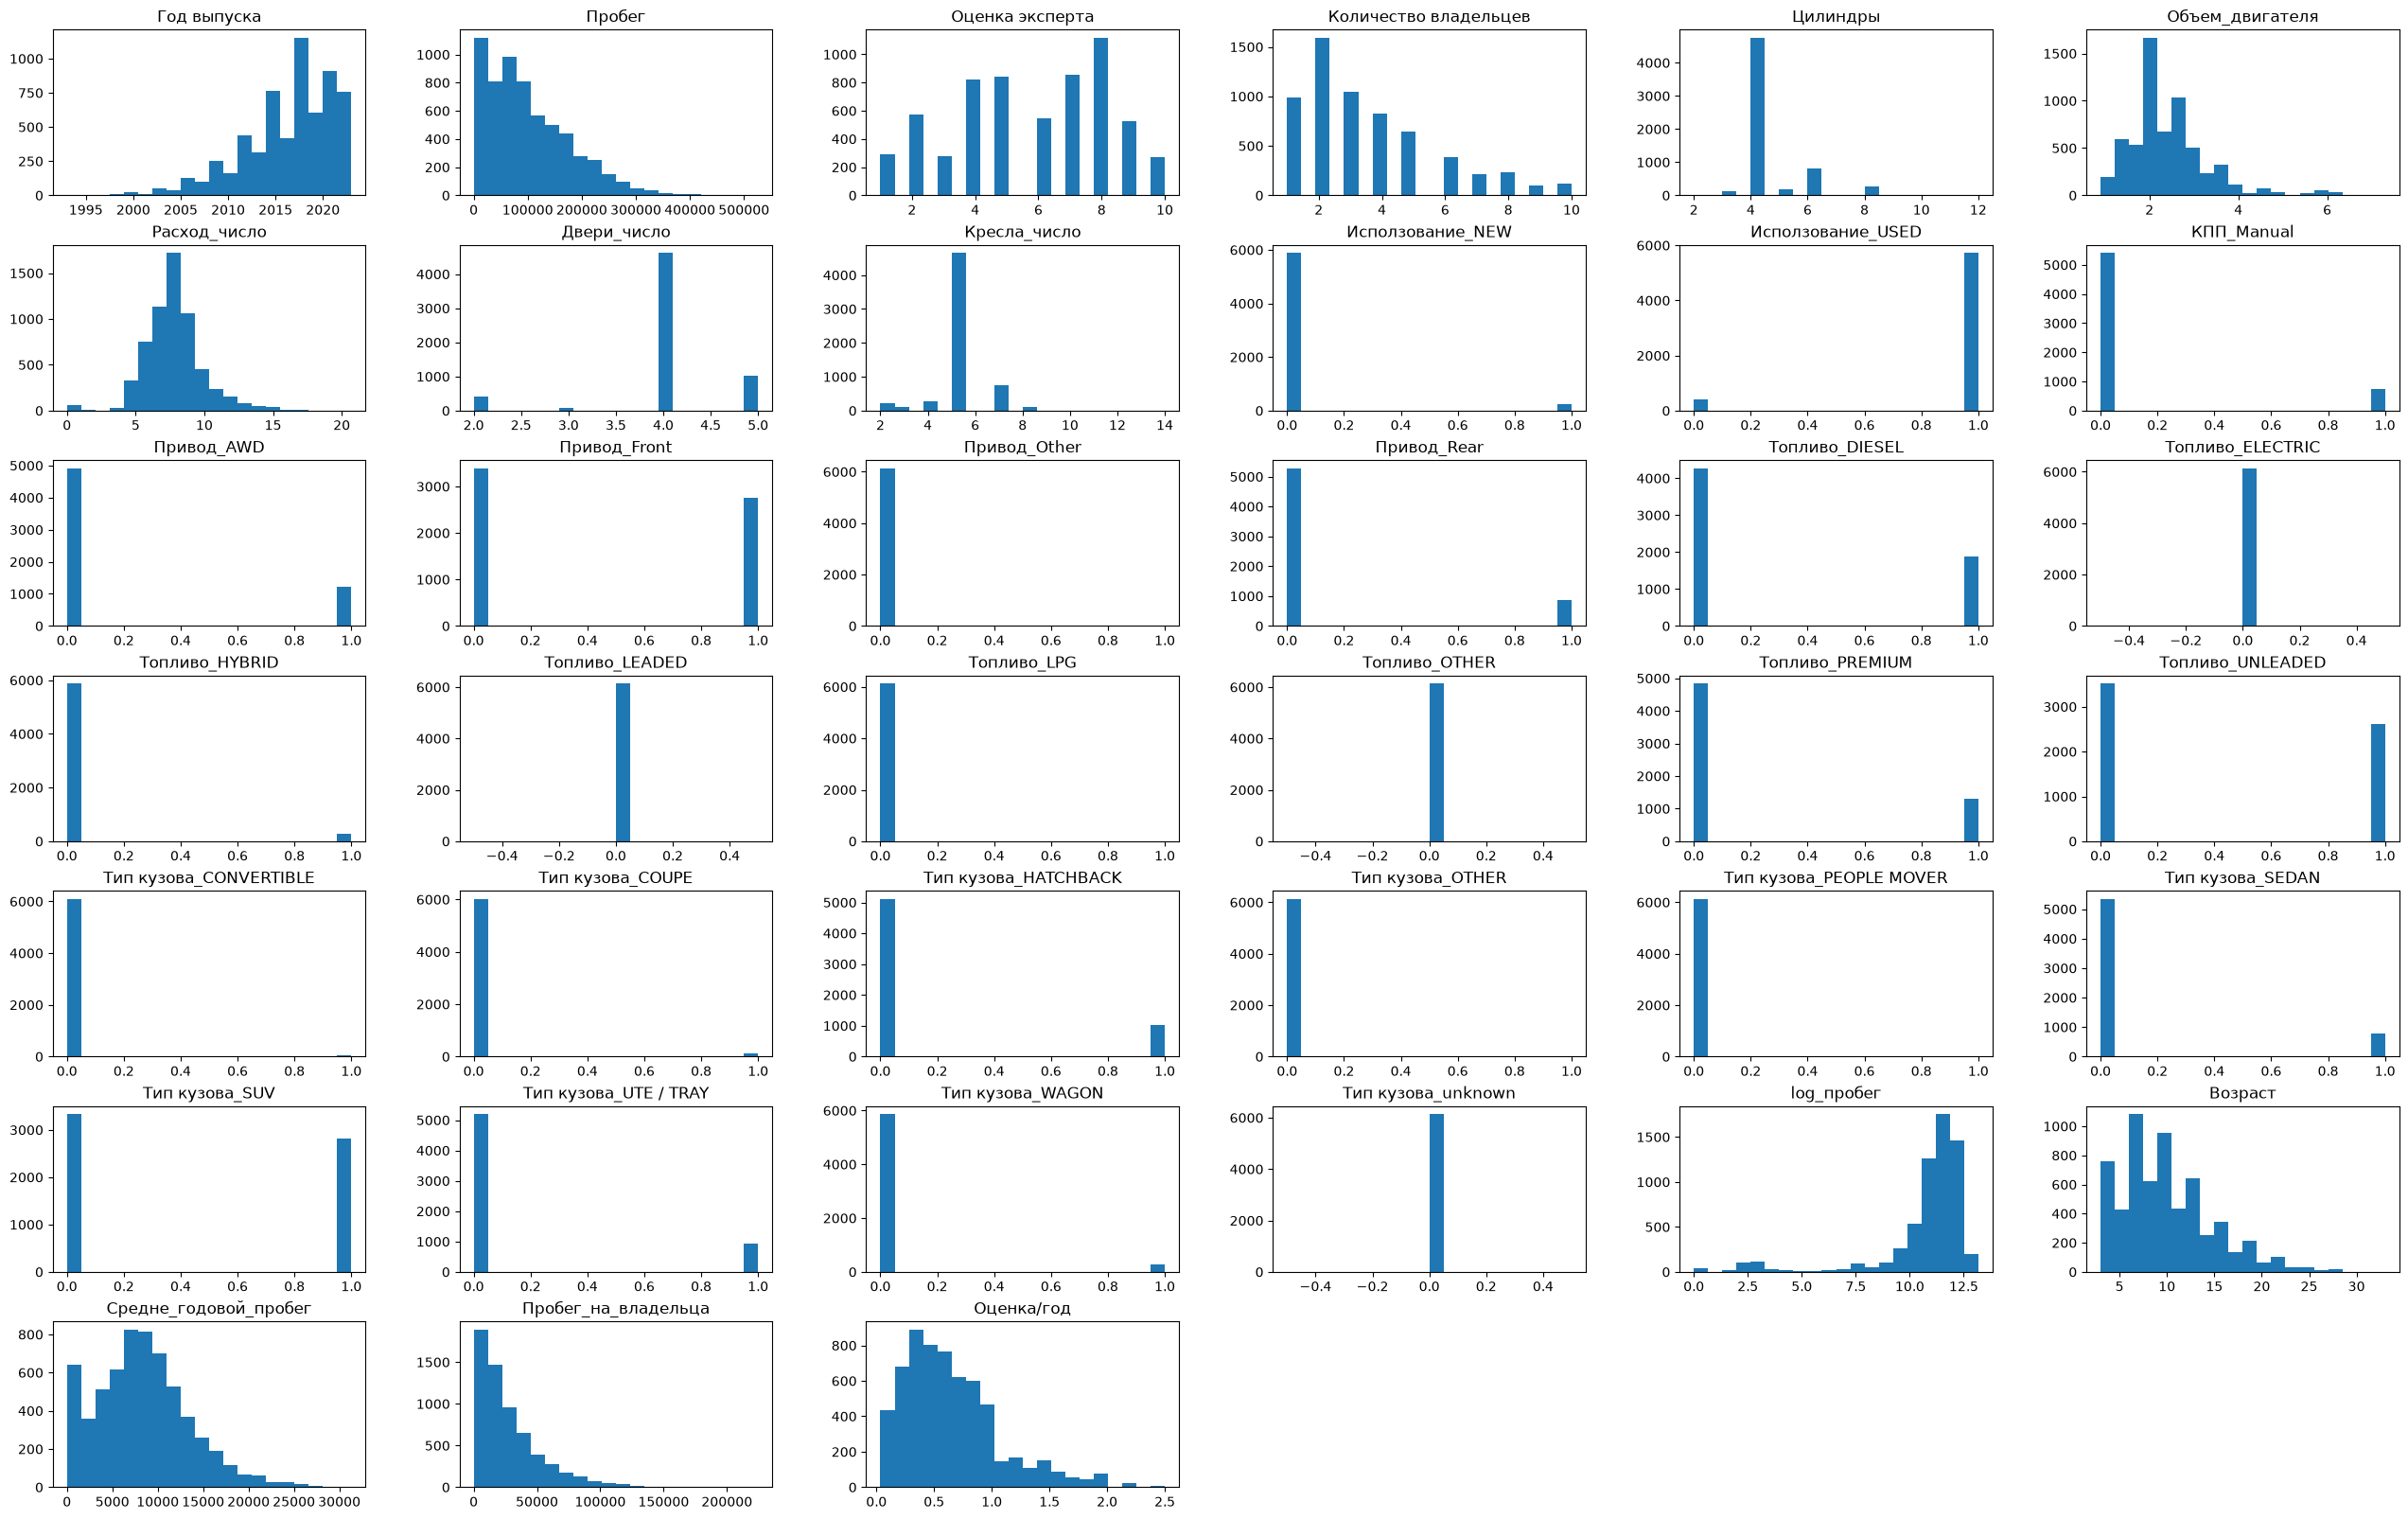

In [7]:
df_num_features = dfx_price.drop(columns='Цена').select_dtypes(include=['float64', 'float32', 'float16', 'int']).copy()

df_num_features.hist(figsize=(32, 20), bins=20, grid=False)
plt.show()

In [8]:
dfx_price = dfx_price[dfx_price['Пробег'] <= 500000]
dfx_price = dfx_price[dfx_price['Год выпуска'] >= 1995]
dfx_price = dfx_price[dfx_price['Цена'] <= 250000]

### Clean Res

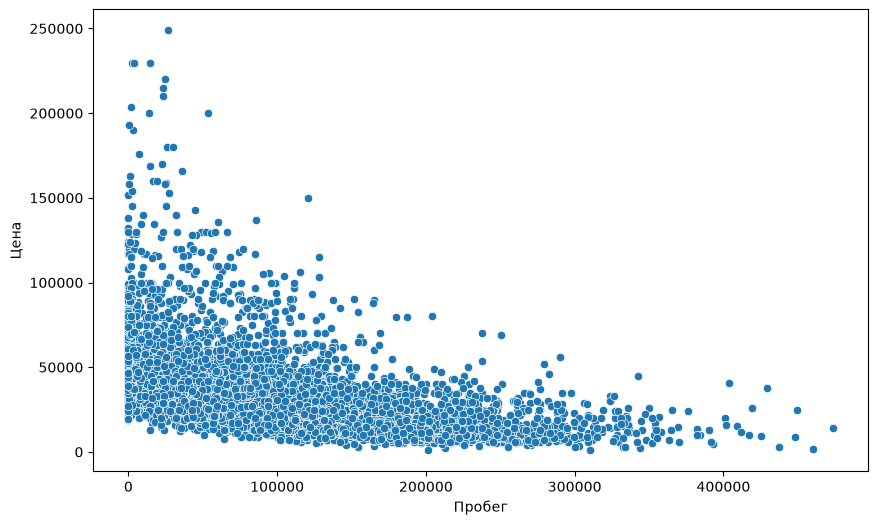

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dfx_price, x='Пробег', y='Цена')
plt.show()

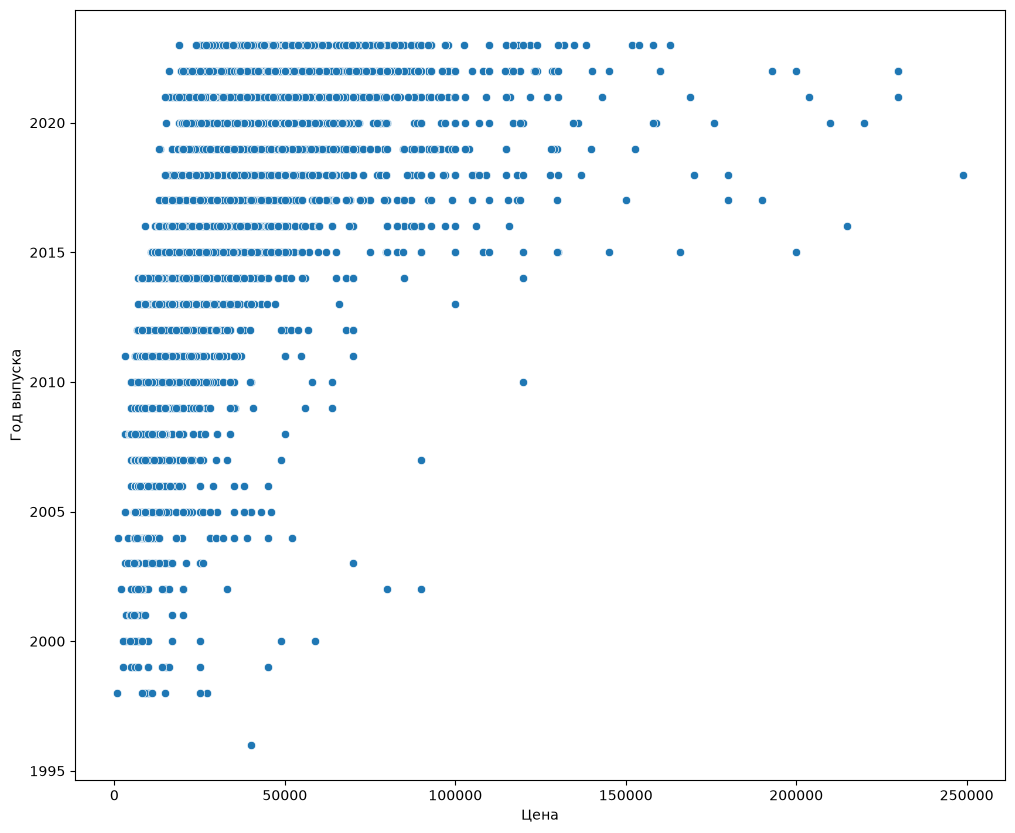

In [10]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=dfx_price, y='Год выпуска', x='Цена')
plt.show()

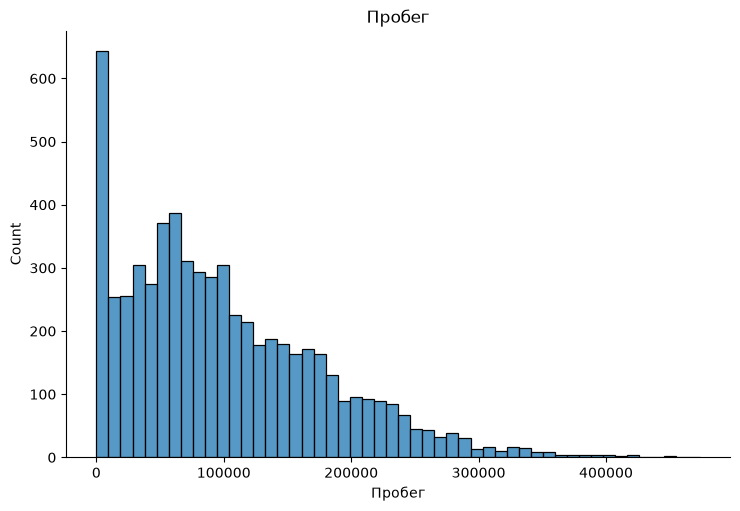

In [11]:
graph = sns.displot(dfx_price['Пробег'], bins=50, height=5, aspect=1.5)

plt.title(f'Пробег')
plt.show()

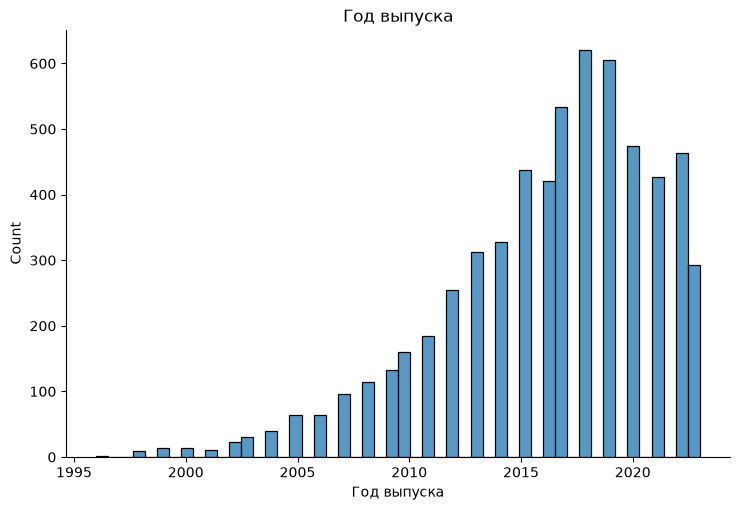

In [12]:
graph = sns.displot(dfx_price['Год выпуска'], bins=50, height=5, aspect=1.5)

plt.title(f'Год выпуска')
plt.show()

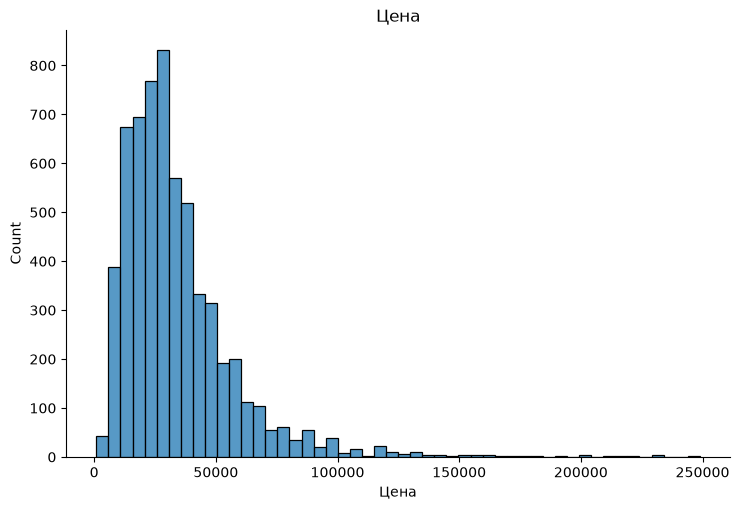

In [13]:
graph = sns.displot(dfx_price["Цена"], bins=50, height=5, aspect=1.5)

plt.title(f'Цена')
plt.show()

# Correlation

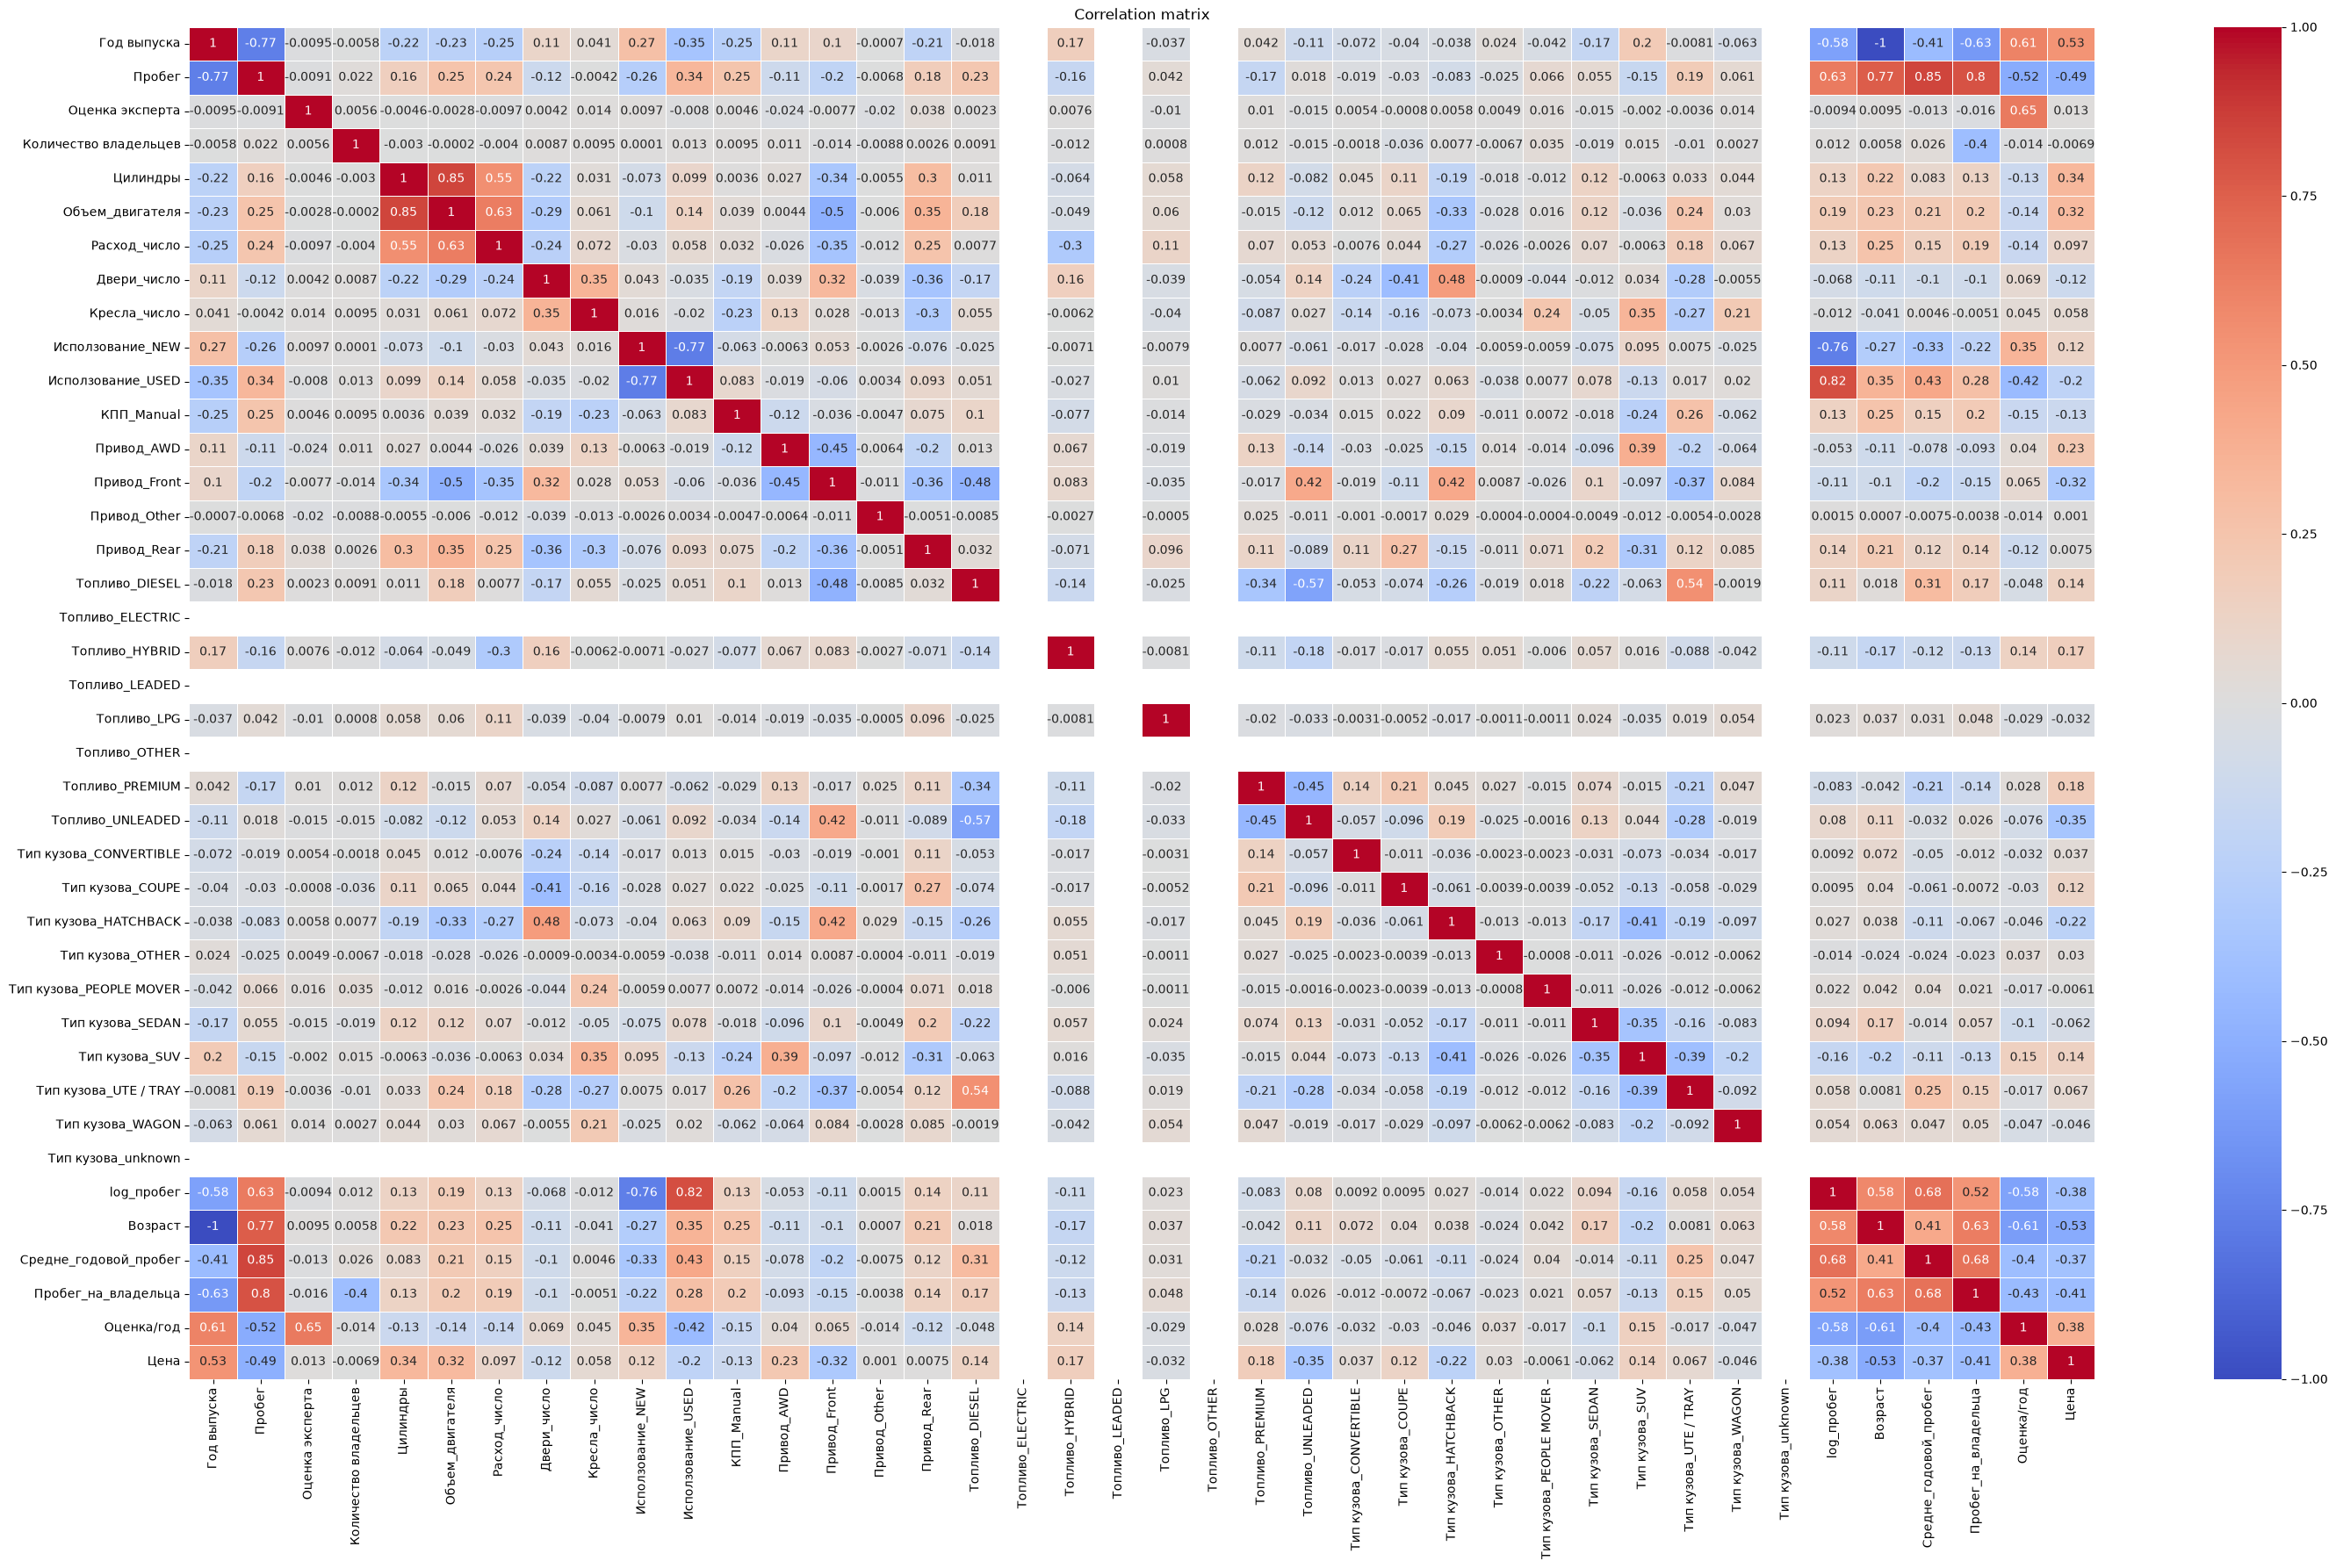

In [14]:
df_corr = dfx_price.select_dtypes('number')
corr_matrix = df_corr.corr()
corr_matrix = np.round(corr_matrix, 4)
plt.figure(figsize=(35, 20))

sns.heatmap(corr_matrix, annot=True, linewidths=.5, cmap='coolwarm')

plt.title('Correlation matrix')
plt.show()

In [15]:
dfxtst_final.shape

(8341, 47)

# Learning

In [16]:
from catboost import CatBoostRegressor
from pandas import col
from sklearn.model_selection import KFold

dfx_final = dfx_price

kf = KFold(n_splits=5)
j = 0
mapes = []
preds = []

for train_idx, val_idx in kf.split(dfx_price):
    train = dfx_final.iloc[train_idx].copy()
    val = dfx_final.iloc[val_idx].copy()

    brand_medians = train.groupby("Бренд")["Цена"].median()
    brand_categories = pd.qcut(brand_medians, q=4, labels=['budget', 'economy', 'comfort', 'premium'])
    brands_dict = brand_categories.to_dict()

    train['категория'] = train['Бренд'].map(brands_dict).fillna('economy').astype(str)
    val['категория'] = val['Бренд'].map(brands_dict).fillna('economy').astype(str)
    train = pd.get_dummies(train, columns=["категория"], drop_first=True, dtype=int)

    brands = []
    for i in range(len(dfx_final.columns)):
        if dfx_final.columns[i].startswith('категория_'):
            brands.append(dfx_final.columns[i]) 

    privod = []
    for i in range(len(dfx_final.columns)):
        if dfx_final.columns[i].startswith('Привод_'):
            privod.append(dfx_final.columns[i]) 

    fuel = []
    for i in range(len(dfx_final.columns)):
        if dfx_final.columns[i].startswith('Топливо_'):
            fuel.append(dfx_final.columns[i]) 

    fuel.remove("Топливо_OTHER")
    privod.remove("Привод_Other")

    features = ["Полное название", 'Возраст', "Оценка/год", 'log_пробег', "Цилиндры", "Объем_двигателя", "Средне_годовой_пробег",
                 "Двери_число", "Тип кузова_COUPE", "Тип кузова_HATCHBACK", "Локация"] + brands + privod + fuel
    ct_features = ["Локация"]
    txt_features = ["Полное название"]

    Xtr = train[features].copy()
    ytr_log = np.log1p(train['Цена'])

    Xva = val[features].copy()
    yva = val["Цена"]
    yva_log = np.log1p(yva)

    model = CatBoostRegressor( 
        iterations=5000, 
        learning_rate=0.03, 
        depth=6, 
        random_seed=42 + j, 
        verbose=500,
        thread_count=-1,  
        early_stopping_rounds=100,
    )

    model.fit(Xtr, ytr_log, cat_features=ct_features, text_features=txt_features,eval_set=(Xva,yva_log))

    val_pred = np.expm1(model.predict(Xva))
    mape = mean_absolute_percentage_error(yva, val_pred)
    print(f'ITER {j} - MAPE {mape:.4f}')
    mapes.append(mape)

    ## test data
    dfxtst_iter = dfxtst_final.copy()
    dfxtst_iter['категория'] = dfxtst_iter['Бренд'].map(brands_dict).fillna('economy').astype(str)
    dfxtst_iter = dfxtst_iter.reindex(columns=train.columns, fill_value=0)

    tst_pred_log = model.predict(dfxtst_iter[features])
    preds.append(np.expm1(tst_pred_log))
    

    model.save_model(f"models/model{j}.cbm")
    j+=1



print(f'Mean MAPE - {np.mean(mapes):.4f}')

pred_final = np.mean(preds, axis=0)

ytst = pd.Series(pred_final, name='Цена')
print(ytst)

ytst.to_csv('submission.csv', index=False)
# 
# Архивируем в submission.zip
with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    zipf.write('submission.csv')

0:	learn: 0.6224616	test: 0.6246088	best: 0.6246088 (0)	total: 69.4ms	remaining: 5m 47s
500:	learn: 0.1870398	test: 0.2155585	best: 0.2155585 (500)	total: 6.67s	remaining: 59.9s
1000:	learn: 0.1606232	test: 0.1999475	best: 0.1999475 (1000)	total: 13.4s	remaining: 53.5s
1500:	learn: 0.1443544	test: 0.1928073	best: 0.1928073 (1500)	total: 20.4s	remaining: 47.5s
2000:	learn: 0.1331875	test: 0.1881116	best: 0.1881116 (2000)	total: 27.2s	remaining: 40.7s
2500:	learn: 0.1246707	test: 0.1848639	best: 0.1848639 (2500)	total: 33.8s	remaining: 33.8s
3000:	learn: 0.1173998	test: 0.1826202	best: 0.1826202 (3000)	total: 40.4s	remaining: 26.9s
3500:	learn: 0.1112766	test: 0.1812172	best: 0.1812172 (3500)	total: 46.8s	remaining: 20s
4000:	learn: 0.1060680	test: 0.1799963	best: 0.1799912 (3997)	total: 53.2s	remaining: 13.3s
4500:	learn: 0.1016565	test: 0.1790513	best: 0.1790481 (4496)	total: 59.8s	remaining: 6.63s
4999:	learn: 0.0973886	test: 0.1783321	best: 0.1783321 (4999)	total: 1m 6s	remaining: 0u

# SAVE

In [17]:
import json

with open("models/brands.json", "w", encoding='utf-8') as f:
    json.dump(brands_dict, f, ensure_ascii=False, indent=4)

with open("models/columns.json", "w", encoding='utf-8') as f:
    model_col = list(Xtr.columns)
    json.dump(model_col, f, ensure_ascii=False, indent=4)